<a href="https://colab.research.google.com/github/Rageel-28/244107020136-Machine-Learning/blob/main/JS05/JS05_Tugas2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# JS05 - Klasifikasi 1
## Tugas Lab 2 - Multinomial Naive Bayes: CountVectorizer vs TF-IDF

**Soal:**

1. Buat model klasifikasi Multinomial Naive Bayes dengan ketentuan:
   1. Menggunakan data `spam.csv`
   2. Fitur `CountVectorizer` dengan mengaktifkan **stop_words**
   3. Evaluasi hasilnya
2. Buat model klasifikasi Multinomial Naive Bayes dengan ketentuan:
   1. Menggunakan data `spam.csv`
   2. Fitur `TF-IDF` dengan mengaktifkan **stop_words**
   3. Evaluasi hasilnya dan bandingkan dengan hasil pada soal no 1
   4. Berikan kesimpulan fitur mana yang terbaik pada kasus data `spam.csv`

## Langkah 0 - Persiapan Dataset

In [13]:
# Upload dataset (khusus Google Colab).
# Jika file sudah ada di folder kerja, langkah upload dilewati.
import os

if not os.path.exists('spam.csv'):
    try:
        from google.colab import files
        print('Silakan upload file spam.csv')
        files.upload()
    except ImportError:
        raise FileNotFoundError('spam.csv tidak ditemukan. Letakkan file di folder yang sama dengan notebook ini.')

print('File spam.csv tersedia:', os.path.exists('spam.csv'))

File spam.csv tersedia: True


## Langkah 1 - Load Data dan Preprocessing
Tahapan sama dengan Lab 3: load data, buang 3 kolom kosong, ganti nama kolom, encode label (`spam = 1`, `ham = 0`), lalu pisahkan fitur dan label.

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

df = pd.read_csv('spam.csv', encoding='latin-1')

# Drop kolom tidak terpakai dan ubah nama kolom
df = df.drop(columns=df.columns[2:])
df = df.rename(columns={'v1': 'Labels', 'v2': 'SMS'})

# Inspeksi
print(df['Labels'].value_counts())
print('\n')
df.info()

# Encode label
df['Labels'] = df['Labels'].map({'spam': 1, 'ham': 0})

# Pisahkan fitur dan label
X = df['SMS'].values
y = df['Labels'].values
df.head()

Labels
ham     4825
spam     747
Name: count, dtype: int64


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   Labels  5572 non-null   object
 1   SMS     5572 non-null   object
dtypes: object(2)
memory usage: 87.2+ KB


,Labels,SMS
0,0,"Go until jurong point, crazy.. Available only ..."
1,0,Ok lar... Joking wif u oni...
2,1,Free entry in 2 a wkly comp to win FA Cup fina...
3,0,U dun say so early hor... U c already then say...
4,0,"Nah I don't think he goes to usf, he lives aro..."


## Langkah 2 - Split Data
Pembagian data **sama dengan Lab 3** (80% latih, 20% uji, `random_state=50`) agar hasil dapat dibandingkan langsung dengan hasil Lab 3. Split dilakukan **sebelum** ekstraksi fitur untuk mencegah *information leakage*.

In [3]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=50)

print('Jumlah data latih:', len(X_train), '| Jumlah data uji:', len(X_test))
print('Proporsi spam data latih:', round(y_train.mean(), 4))
print('Proporsi spam data uji  :', round(y_test.mean(), 4))

Jumlah data latih: 4457 | Jumlah data uji: 1115
Proporsi spam data latih: 0.1315
Proporsi spam data uji  : 0.1444


## Langkah 3 - Fungsi Evaluasi
Karena kelas tidak seimbang (spam hanya sekitar 13%), selain akurasi dihitung juga **precision, recall, dan f1-score untuk kelas spam**. Fungsi ini dipakai untuk kedua model agar perlakuannya identik.

In [4]:
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             confusion_matrix, classification_report, ConfusionMatrixDisplay)

def evaluasi(nama, model, Xtr, ytr, Xte, yte):
    pred_tr = model.predict(Xtr)
    pred_te = model.predict(Xte)

    print(f'===== {nama} =====')
    print(f'Akurasi data train : {accuracy_score(ytr, pred_tr):.4f}')
    print(f'Akurasi data test  : {accuracy_score(yte, pred_te):.4f}')
    print('\nConfusion Matrix (baris = aktual, kolom = prediksi):')
    print(confusion_matrix(yte, pred_te))
    print('\nLaporan Klasifikasi (data test):')
    print(classification_report(yte, pred_te, target_names=['ham', 'spam'], digits=4))

    ConfusionMatrixDisplay.from_predictions(yte, pred_te, display_labels=['ham', 'spam'], cmap='Blues')
    plt.title(f'Confusion Matrix - {nama}')
    plt.show()

    return {
        'Model': nama,
        'Akurasi Train': accuracy_score(ytr, pred_tr),
        'Akurasi Test': accuracy_score(yte, pred_te),
        'Precision (spam)': precision_score(yte, pred_te),
        'Recall (spam)': recall_score(yte, pred_te),
        'F1 (spam)': f1_score(yte, pred_te),
    }

---
# Soal 1 - Multinomial NB + CountVectorizer (stop_words aktif)
`CountVectorizer(stop_words='english')` menghapus kata-kata umum bahasa Inggris (misalnya *the, is, to, and*) yang kurang informatif sebelum dihitung frekuensinya.

### 1a. Ekstraksi Fitur

In [5]:
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB

# fit_transform hanya pada data latih; data uji hanya transform
bow = CountVectorizer(stop_words='english')
X_train_bow = bow.fit_transform(X_train)
X_test_bow = bow.transform(X_test)

print('Jumlah fitur (kosakata) :', len(bow.get_feature_names_out()))
print('Dimensi data latih      :', X_train_bow.shape)
print('Dimensi data uji        :', X_test_bow.shape)

Jumlah fitur (kosakata) : 7466
Dimensi data latih      : (4457, 7466)
Dimensi data uji        : (1115, 7466)


### 1b. Training Model

In [6]:
mnb_bow = MultinomialNB()
mnb_bow.fit(X_train_bow, y_train)

MultinomialNB()

### 1c. Evaluasi

===== CountVectorizer + stop_words =====
Akurasi data train : 0.9946
Akurasi data test  : 0.9830

Confusion Matrix (baris = aktual, kolom = prediksi):
[[951   3]
 [ 16 145]]

Laporan Klasifikasi (data test):
              precision    recall  f1-score   support

         ham     0.9835    0.9969    0.9901       954
        spam     0.9797    0.9006    0.9385       161

    accuracy                         0.9830      1115
   macro avg     0.9816    0.9487    0.9643      1115
weighted avg     0.9829    0.9830    0.9827      1115



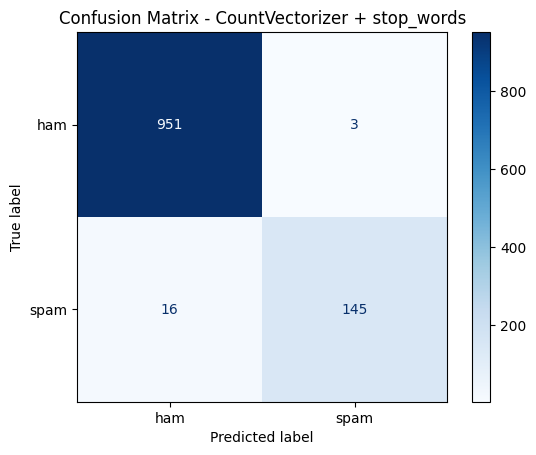

In [7]:
hasil_bow = evaluasi('CountVectorizer + stop_words', mnb_bow, X_train_bow, y_train, X_test_bow, y_test)

---
# Soal 2 - Multinomial NB + TF-IDF (stop_words aktif)
`TfidfVectorizer(stop_words='english')` memberi bobot kata berdasarkan *Term Frequency x Inverse Document Frequency*: kata yang sering muncul di satu dokumen tetapi jarang di seluruh dokumen mendapat bobot lebih tinggi.

### 2a. Ekstraksi Fitur

In [8]:
tfidf = TfidfVectorizer(stop_words='english')
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

print('Jumlah fitur (kosakata) :', len(tfidf.get_feature_names_out()))
print('Dimensi data latih      :', X_train_tfidf.shape)
print('Dimensi data uji        :', X_test_tfidf.shape)

Jumlah fitur (kosakata) : 7466
Dimensi data latih      : (4457, 7466)
Dimensi data uji        : (1115, 7466)


### 2b. Training Model

In [9]:
mnb_tfidf = MultinomialNB()
mnb_tfidf.fit(X_train_tfidf, y_train)

MultinomialNB()

### 2c. Evaluasi

===== TF-IDF + stop_words =====
Akurasi data train : 0.9843
Akurasi data test  : 0.9605

Confusion Matrix (baris = aktual, kolom = prediksi):
[[954   0]
 [ 44 117]]

Laporan Klasifikasi (data test):
              precision    recall  f1-score   support

         ham     0.9559    1.0000    0.9775       954
        spam     1.0000    0.7267    0.8417       161

    accuracy                         0.9605      1115
   macro avg     0.9780    0.8634    0.9096      1115
weighted avg     0.9623    0.9605    0.9579      1115



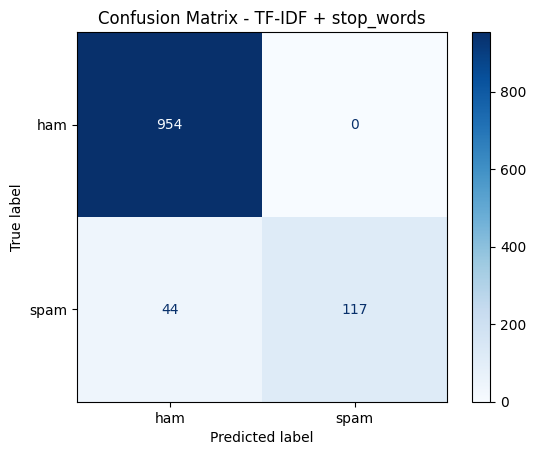

In [10]:
hasil_tfidf = evaluasi('TF-IDF + stop_words', mnb_tfidf, X_train_tfidf, y_train, X_test_tfidf, y_test)

### 2d. Perbandingan Hasil
Tabel membandingkan kedua model pada data uji yang sama. Sebagai pembanding tambahan, ditampilkan juga baseline Lab 3 (`CountVectorizer` **tanpa** stop_words).

,Akurasi Train,Akurasi Test,Precision (spam),Recall (spam),F1 (spam)
Model,,,,,
Baseline Lab 3 (CountVectorizer tanpa stop_words),0.9946,0.9776,0.9789,0.8634,0.9175
CountVectorizer + stop_words,0.9946,0.9830,0.9797,0.9006,0.9385
TF-IDF + stop_words,0.9843,0.9605,1.0000,0.7267,0.8417


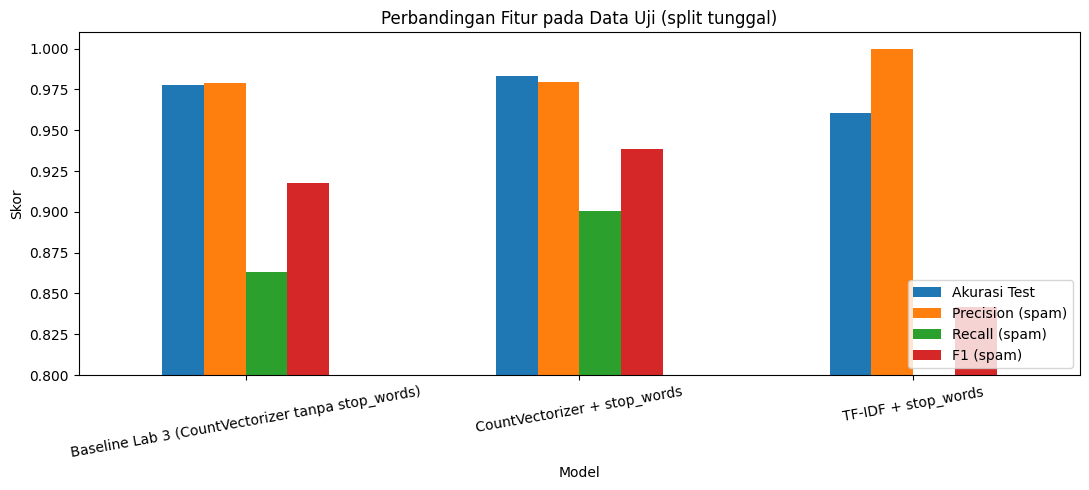

In [11]:
# Baseline Lab 3: CountVectorizer tanpa stop_words
bow_dasar = CountVectorizer()
Xtr_dasar = bow_dasar.fit_transform(X_train)
Xte_dasar = bow_dasar.transform(X_test)
mnb_dasar = MultinomialNB().fit(Xtr_dasar, y_train)
pred_dasar = mnb_dasar.predict(Xte_dasar)
hasil_dasar = {
    'Model': 'Baseline Lab 3 (CountVectorizer tanpa stop_words)',
    'Akurasi Train': accuracy_score(y_train, mnb_dasar.predict(Xtr_dasar)),
    'Akurasi Test': accuracy_score(y_test, pred_dasar),
    'Precision (spam)': precision_score(y_test, pred_dasar),
    'Recall (spam)': recall_score(y_test, pred_dasar),
    'F1 (spam)': f1_score(y_test, pred_dasar),
}

perbandingan = pd.DataFrame([hasil_dasar, hasil_bow, hasil_tfidf]).set_index('Model')
display(perbandingan.round(4))

ax = perbandingan[['Akurasi Test', 'Precision (spam)', 'Recall (spam)', 'F1 (spam)']].plot(
    kind='bar', figsize=(11, 5), rot=10)
plt.title('Perbandingan Fitur pada Data Uji (split tunggal)')
plt.ylabel('Skor')
plt.ylim(0.8, 1.01)
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

### 2e. Validasi Tambahan: 5-Fold Cross Validation
Perbedaan antar fitur pada satu kali split bisa jadi hanya kebetulan. Maka kedua fitur dibandingkan lagi dengan **5-fold stratified cross validation pada seluruh data** (vectorizer di dalam `Pipeline` sehingga di-fit ulang pada tiap fold).

In [12]:
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import StratifiedKFold, cross_validate

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
metrik = {'accuracy': 'accuracy', 'precision': 'precision', 'recall': 'recall', 'f1': 'f1'}

pipelines = {
    'CountVectorizer + stop_words': make_pipeline(CountVectorizer(stop_words='english'), MultinomialNB()),
    'TF-IDF + stop_words': make_pipeline(TfidfVectorizer(stop_words='english'), MultinomialNB()),
}

baris = []
for nama, pipe in pipelines.items():
    cv = cross_validate(pipe, X, y, cv=skf, scoring=metrik)
    baris.append({
        'Model': nama,
        'Akurasi (mean)': cv['test_accuracy'].mean(),
        'Akurasi (std)': cv['test_accuracy'].std(),
        'Precision spam': cv['test_precision'].mean(),
        'Recall spam': cv['test_recall'].mean(),
        'F1 spam (mean)': cv['test_f1'].mean(),
        'F1 spam (std)': cv['test_f1'].std(),
    })

hasil_cv = pd.DataFrame(baris).set_index('Model')
display(hasil_cv.round(4))

,Akurasi (mean),Akurasi (std),Precision spam,Recall spam,F1 spam (mean),F1 spam (std)
Model,,,,,,
CountVectorizer + stop_words,0.9856,0.0020,0.9575,0.9344,0.9457,0.0078
TF-IDF + stop_words,0.9709,0.0023,0.9984,0.7844,0.8784,0.0113


---
# Kesimpulan dan Jawaban Tugas Lab 2

### Hasil pada data uji (1115 SMS; 161 di antaranya spam)
| Fitur | Akurasi | Precision (spam) | Recall (spam) | F1 (spam) |
|---|---|---|---|---|
| Baseline Lab 3 (CountVectorizer, tanpa stop_words) | 0.9776 | 0.9789 | 0.8634 | 0.9175 |
| **CountVectorizer + stop_words** | **0.9830** | 0.9797 | **0.9006** | **0.9385** |
| TF-IDF + stop_words | 0.9605 | **1.0000** | 0.7267 | 0.8417 |

Confusion matrix (aktual x prediksi):

- CountVectorizer + stop_words: 951 ham benar, **3** ham salah dikira spam, **16** spam lolos (dianggap ham), 145 spam benar.
- TF-IDF + stop_words: 954 ham benar, **0** ham salah dikira spam, **44** spam lolos, 117 spam benar.

### Validasi 5-fold cross validation (seluruh data)
| Fitur | Akurasi | Precision spam | Recall spam | F1 spam |
|---|---|---|---|---|
| **CountVectorizer + stop_words** | **0.9856** | 0.9575 | **0.9344** | **0.9457** |
| TF-IDF + stop_words | 0.9709 | **0.9984** | 0.7844 | 0.8784 |

### Kesimpulan: fitur terbaik
**CountVectorizer (dengan stop_words) adalah fitur terbaik untuk data `spam.csv`** karena memiliki akurasi, recall spam, dan f1-score spam yang lebih tinggi, baik pada satu kali split maupun pada cross validation (konsisten pada kedua cara evaluasi).

Penjelasan:

- **TF-IDF sangat "hati-hati"**: precision spam hampir sempurna (tidak ada ham yang salah ditandai spam pada data uji), tetapi banyak spam yang lolos (recall hanya 0.727 pada data uji dan 0.784 pada CV). Pada deteksi spam, SMS spam yang lolos merupakan kegagalan utama model.
- Dugaan penyebabnya (belum diuji di notebook ini): bobot TF-IDF berupa pecahan kecil yang ternormalisasi, sedangkan Multinomial NB bekerja pada hitungan kata. Dengan *smoothing* default (`alpha = 1`), pengaruhnya relatif lebih besar terhadap nilai-nilai kecil tersebut, sehingga peluang kata cenderung seragam dan model condong ke kelas mayoritas (ham).
- Penggunaan **stop_words** pada CountVectorizer memberi perbaikan kecil terhadap baseline Lab 3 (f1 spam 0.9175 menjadi 0.9385), namun perbandingan ini berasal dari satu kali split sehingga sebaiknya dipandang sebagai indikasi, bukan bukti kuat.
- Jika prioritas utama adalah **tidak boleh ada pesan sah yang salah diblokir**, TF-IDF (precision 1.0) dapat dipertimbangkan, tetapi dengan konsekuensi lebih banyak spam yang lolos. Untuk keseimbangan terbaik antara keduanya (f1-score), pilihannya tetap CountVectorizer.